# Product Analytics: eCommerce Events & Conversion Funnel

### Business Context

The dataset contains e-commerce user activity from an electronics store. Each row represents an event generated by a user, such as viewing a product, adding it to the cart, or purchasing it.

The goal of this analysis is to understand how users move through the purchase journey and identify the stages and segments where the biggest drop-offs occur.

---

### Business Question

> **Where do users drop off in the e-commerce purchase funnel, and which product or behavioral factors are associated with higher conversion?**

---

### User Journey

Because the dataset does not contain registration events, we will not use registration as the first funnel step.

*Our main funnel will be:*

**View → Cart → Purchase**

---

### Primary KPI

**Purchase Conversion Rate** - the percentage of sessions that complete a purchase after viewing a product.

### Secondary Metrics:

- **View → Cart Conversion** - how often product views result in adding a product to the cart.
- **Cart → Purchase Conversion** - how often users who add a product to the cart complete a purchase.
- **View → Purchase Conversion** - overall conversion from product view to purchase.
- **Time to Purchase** - how much time passes between key funnel events.


## Data Understanding & Data Quality

### Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import ScalarFormatter

In [2]:
import kagglehub

path = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-electronics-store")

print("Path to dataset files:", path)

100%|██████████| 20.3M/20.3M [00:00<00:00, 74.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-electronics-store/versions/1


In [3]:
import os
os.listdir(path)

['events.csv']

In [4]:
file_path = f"{path}/events.csv"

df = pd.read_csv(file_path)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


### Dataset structure

In [5]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

df.info()

Rows: 885,129
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [6]:
df.dtypes

,0
event_time,object
event_type,object
product_id,int64
category_id,int64
category_code,object
brand,object
price,float64
user_id,int64
user_session,object


In [7]:
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

print(f"Start: {df['event_time'].min()}")
print(f"End: {df['event_time'].max()}")

Start: 2020-09-24 11:57:06+00:00
End: 2021-02-28 23:59:09+00:00


In [8]:
df['event_type'].unique()

array(['view', 'cart', 'purchase'], dtype=object)

The dataset contains **885 129 e-commerce events** across 9 columns.

Each row represents **one event related to a product**, rather than a unique user or a completed purchase. The same user can generate multiple events and multiple sessions.

The dataset covers the period **from September 24, 2020 to February 28, 2021**.

The available event types are:

- view
- cart
- purchase

The dataset contains information about the event timestamp, product, category, brand, price, user and session. The `event_time` column was converted from object to datetime to enable time-based analysis.

This structure allows us to analyze the customer journey from product **view → cart → purchase**.

### Users & Sessions

In [9]:
print(f'Unique users: {df['user_id'].nunique()}')
print(f'Unique sessions: {df['user_session'].nunique()}')

print(f'Average events per user: {len(df) / df["user_id"].nunique():.2f}')
print(f'Average events per session: {len(df) / df["user_session"].nunique():.2f}')

Unique users: 407283
Unique sessions: 490398
Average events per user: 2.17
Average events per session: 1.80


### Data Quality

In [10]:
# missing
df.isna().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,236219
brand,212364
price,0
user_id,0
user_session,165


In [11]:
# duplicates
df.duplicated().sum()

np.int64(655)

In [12]:
df[df.duplicated(keep=False)]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
511,2020-09-24 13:51:07+00:00,view,387956,2144415922427789416,computers.components.videocards,asus,104.21,1515915625519429853,PZu2caZ5EN
512,2020-09-24 13:51:07+00:00,view,387956,2144415922427789416,computers.components.videocards,asus,104.21,1515915625519429853,PZu2caZ5EN
974,2020-09-24 15:48:55+00:00,view,874667,2144415922738167921,computers.components.cdrw,asus,23.48,1515915625519457150,8wvs0vbHtv
975,2020-09-24 15:48:55+00:00,view,874667,2144415922738167921,computers.components.cdrw,asus,23.48,1515915625519457150,8wvs0vbHtv
4827,2020-09-25 13:15:09+00:00,view,453469,2144415924222951574,auto.accessories.parktronic,NaN,69.84,1515915625519725870,9ofICyh8Eo
...,...,...,...,...,...,...,...,...,...
878751,2021-02-27 17:56:05+00:00,view,1571204,2144415924491387038,computers.components.motherboard,asus,146.40,1515915625610505518,EUqy2lyCvY
879544,2021-02-27 20:54:20+00:00,view,1027953,2144415923837075596,electronics.audio.acoustic,jbl,332.87,1515915625529755153,3mD3HIQ017
879545,2021-02-27 20:54:20+00:00,view,1027953,2144415923837075596,electronics.audio.acoustic,jbl,332.87,1515915625529755153,3mD3HIQ017
882715,2021-02-28 14:18:02+00:00,view,4078916,2144415922427789416,computers.components.videocards,sapphire,415.54,1515915625610828170,21hX1rWtum


In [13]:
# invalid
print(f'Zero prices: {(df["price"] == 0).sum()}')
print(f'Negative prices: {(df["price"] < 0).sum()}')

Zero prices: 0
Negative prices: 0


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_id,885129.0,1.906621e+06,1.458708e+06,1.020000e+02,6.988030e+05,1.452883e+06,3.721194e+06,4.183880e+06
category_id,885129.0,2.144423e+18,6.165105e+14,2.144416e+18,2.144416e+18,2.144416e+18,2.144416e+18,2.227847e+18
price,885129.0,1.463287e+02,2.968077e+02,2.200000e-01,2.646000e+01,6.571000e+01,1.904900e+02,6.477106e+04
user_id,885129.0,1.515916e+18,3.747287e+07,1.515916e+18,1.515916e+18,1.515916e+18,1.515916e+18,1.515916e+18


The dataset is generally suitable for further analysis. There are no missing values in key fields such as `event_time`, `event_type`, `product_id`, `category_id`, `price`, and `user_id`.

Missing values are mainly concentrated in the `category_code` and `brand` fields. Since these fields are not required for calculating the overall conversion funnel, these records will not be deleted at this stage. Instead, we will label the missing values as **"Unknown"**.

Only **165 events** are missing the `user_session` field, so these records will have a minimal impact on the overall analysis but may be excluded from session-level calculations.

We also found **655 exact duplicate row**s and no zero or negative prices. Duplicate records will be removed before further analysis.

In [15]:
# fill missing
df['category_code'] = df['category_code'].fillna('Unknown')
df['brand'] = df['brand'].fillna('Unknown')

# remove duplicates
df = df.drop_duplicates()

print(f'Rows after cleaning: {len(df)}')
print(f'Missing values remaining: {df.isna().sum().sum():,}')

Rows after cleaning: 884474
Missing values remaining: 162


In [16]:
df.isna().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,162


### Event Distribution

In [17]:
event_distribution = df['event_type'].value_counts().rename_axis('event_type').reset_index(name='events')

event_distribution['share'] = (event_distribution['events'] / len(df) * 100).round(2)

event_distribution

,event_type,events,share
0,view,793099,89.67
1,cart,54032,6.11
2,purchase,37343,4.22


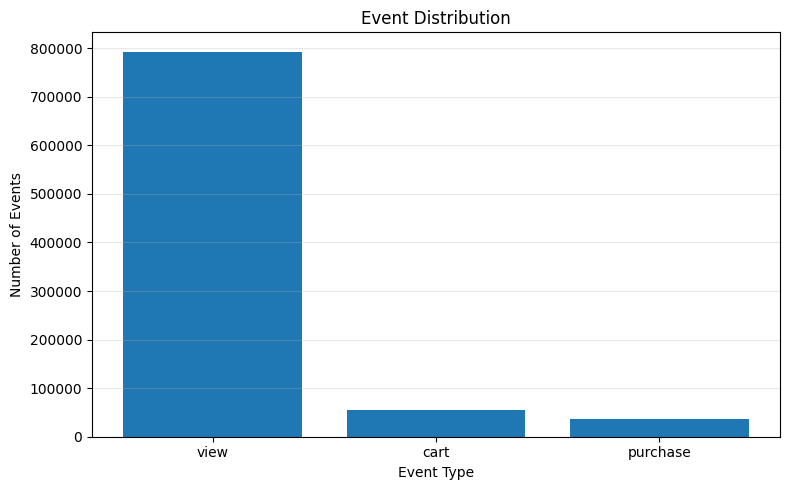

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(event_distribution['event_type'], event_distribution['events'])

plt.title('Event Distribution')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The event distribution is highly concentrated in product views: **89.67%** of all events are **view events**. **cart events** account for **6.11%**, while **purchase events** represent only **4.22%**.

This shows a substantial decrease in event activity from product browsing to cart and purchase. However, these figures are based on event counts rather than unique users or sessions, so they cannot be interpreted as conversion rates yet.

Therefore, the next step is to build the actual conversion funnel and measure how many users/sessions progress from **view → cart → purchase**.

## Exploratory Product Analysis

Now that we've figured out the dataset and verified its quality, we can move from individual events to analyzing behavior at the user and session levels.

The goal of this section is to understand how actively users interact with the store and what level of activity is typically observed during a single session. Since particularly active users can significantly skew average metrics, we'll look not only at the mean and median but also at the percentiles.

### User Activity

In [19]:
user_activity = df.groupby('user_id').agg(
    events = ('event_type', 'count'), sessions = ('user_session', 'nunique'), products = ('product_id', 'nunique') ).reset_index()

user_activity.head()

,user_id,events,sessions,products
0,1515915625353226922,1,1,1
1,1515915625353230067,1,1,1
2,1515915625353230683,13,4,10
3,1515915625353230922,1,1,1
4,1515915625353234047,36,1,8


In [20]:
user_activity[['events', 'sessions', 'products']].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
events,407283.0,2.171645,4.405437,1.0,1.0,4.0,6.0,16.0,572.0
sessions,407283.0,1.204649,1.278919,0.0,1.0,2.0,2.0,4.0,254.0
products,407283.0,1.366838,1.562091,1.0,1.0,2.0,3.0,7.0,169.0


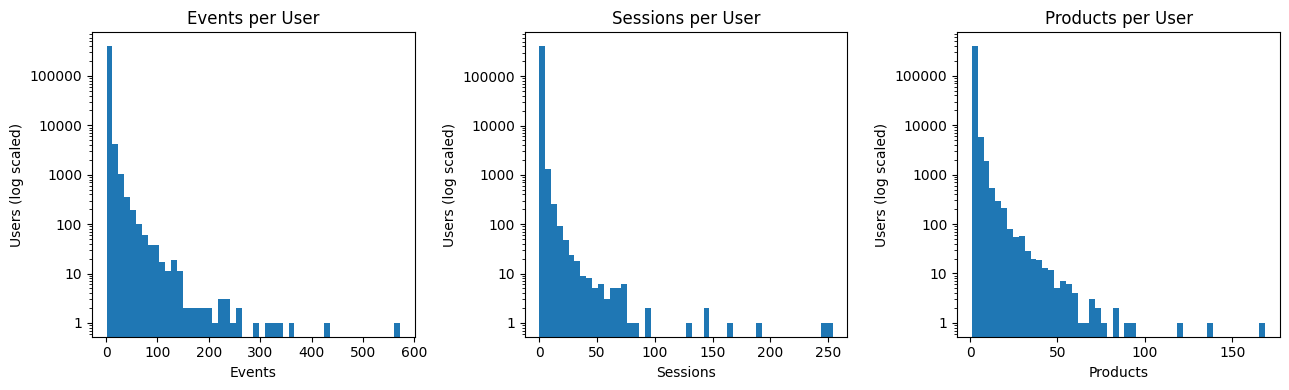

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))

ax[0].hist(user_activity['events'], bins=50)
ax[0].set_title('Events per User')
ax[0].set_xlabel('Events')
ax[0].set_ylabel('Users (log scaled)')
ax[0].set_yscale('log')
ax[0].yaxis.set_major_formatter(ScalarFormatter())  # 10^2 to 100

ax[1].hist(user_activity['sessions'], bins=50)
ax[1].set_title('Sessions per User')
ax[1].set_xlabel('Sessions')
ax[1].set_ylabel('Users (log scaled)')
ax[1].set_yscale('log')
ax[1].yaxis.set_major_formatter(ScalarFormatter())

ax[2].hist(user_activity['products'], bins=50)
ax[2].set_title('Products per User')
ax[2].set_xlabel('Products')
ax[2].set_ylabel('Users (log scaled)')
ax[2].set_yscale('log')
ax[2].yaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

User activity is strongly right-skewed across all three metrics.

The **median user** generated only **1 event**, interacted with **1 session** and interacted with **1 unique product**. At the same time, the **mean number of events** per user was higher at **2.17**, while the **mean number of sessions and unique products** was **1.20 and 1.37**, respectively.

The difference between the median and mean is driven by a relatively small group of highly active users. For example, **95% of users** generated no more than **6 events**, while the **top 1%** generated **16 or more events**. The maximum reached **572 events** per user.

A similar pattern can be seen for sessions and products: **95% of users** had no more than **2 sessions** and interacted with no more than **3 unique products**.

Therefore, using the mean alone would not accurately describe typical user behavior. For the following analysis, we will keep the skewed distribution in mind and use median and percentiles alongside the mean.

Overall, the data suggests that a typical user has a relatively short interaction with the store, while a small group of highly active users generates a disproportionately large number of events.

### Extreme Users Check

In [22]:
print("Top users by events:")
display(user_activity.nlargest(10, 'events'))

print("\nTop users by sessions:")
display(user_activity.nlargest(10, 'sessions'))

print("\nTop users by products:")
display(user_activity.nlargest(10, 'products'))

Top users by events:


,user_id,events,sessions,products
210031,1515915625554995474,572,1,9
64167,1515915625527763086,424,1,18
283996,1515915625591251010,363,74,35
286408,1515915625591659523,339,3,136
135056,1515915625537803839,329,254,13
249967,1515915625568273951,312,244,6
344625,1515915625599852988,288,23,169
337121,1515915625598794428,260,1,121
123939,1515915625536567608,259,12,90
302506,1515915625593948004,246,22,34



Top users by sessions:


,user_id,events,sessions,products
135056,1515915625537803839,329,254,13
249967,1515915625568273951,312,244,6
322843,1515915625596734979,238,190,14
76739,1515915625529330827,183,166,1
107525,1515915625533483156,148,147,2
5607,1515915625513599785,145,143,1
5416,1515915625512176731,153,131,1
153294,1515915625539946579,127,96,16
378159,1515915625605960935,96,95,1
207578,1515915625551553663,129,84,5



Top users by products:


,user_id,events,sessions,products
344625,1515915625599852988,288,23,169
286408,1515915625591659523,339,3,136
337121,1515915625598794428,260,1,121
2402,1515915625444050265,100,1,95
123939,1515915625536567608,259,12,90
90652,1515915625531156781,113,8,83
130494,1515915625537340014,146,8,82
370,1515915625360775587,116,6,76
270979,1515915625572741657,81,3,74
132782,1515915625537569166,136,1,72


In [23]:
top_user = user_activity.loc[user_activity['events'].idxmax(), 'user_id']

df[df['user_id'] == top_user].sort_values('event_time')

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
410322,2020-12-08 06:13:31+00:00,view,3979136,2144415923744800906,appliances.environment.vacuum,bosch,297.19,1515915625554995474,nFlhu5QzOd
410323,2020-12-08 06:13:38+00:00,view,3979025,2144415923744800906,appliances.environment.vacuum,bosch,350.60,1515915625554995474,nFlhu5QzOd
410324,2020-12-08 06:13:45+00:00,view,3978887,2144415923744800906,appliances.environment.vacuum,bosch,369.17,1515915625554995474,nFlhu5QzOd
410394,2020-12-08 06:36:13+00:00,view,483337,2144415923744800906,appliances.environment.vacuum,thomas,365.25,1515915625554995474,nFlhu5QzOd
410395,2020-12-08 06:36:27+00:00,view,669304,2144415923744800906,appliances.environment.vacuum,thomas,478.59,1515915625554995474,nFlhu5QzOd
...,...,...,...,...,...,...,...,...,...
825626,2021-02-18 07:48:51+00:00,view,247085,2144415923744800906,appliances.environment.vacuum,thomas,262.48,1515915625554995474,nFlhu5QzOd
825699,2021-02-18 07:59:38+00:00,view,483337,2144415923744800906,appliances.environment.vacuum,thomas,365.25,1515915625554995474,nFlhu5QzOd
825700,2021-02-18 07:59:43+00:00,view,847412,2144415923744800906,appliances.environment.vacuum,thomas,120.00,1515915625554995474,nFlhu5QzOd
825701,2021-02-18 07:59:47+00:00,view,37774,2144415923744800906,appliances.environment.vacuum,thomas,167.62,1515915625554995474,nFlhu5QzOd


The **most active user generated 572 events**, which initially looked like a potential outlier. After inspecting the user's events, we found that these events were associated with a single `user_session` that persisted across a long period of time (December 8, 2020 - February 18, 2021).

The user interacted with multiple products and brands, and the events were not concentrated in a short time interval. Therefore, we do not consider this user a clear data anomaly and keep the observations in the dataset.

This also highlights a limitation of the `user_session` field: a session ID in this dataset does not necessarily represent one short continuous visit. Therefore, session-based metrics should be interpreted with caution.

### Session Activity

In [24]:
session_activity = df.groupby('user_session').agg(events = ('event_type', 'count'), products = ('product_id', 'nunique')).reset_index()

session_activity.head()

,user_session,events,products
0,000AMhYaQu,1,1
1,000c34fa-991f-442a-8e07-8c472269bec6,1,1
2,001HttdHUk,1,1
3,001P7lK0Pt,2,2
4,001RxUtFJa,1,1


In [25]:
session_activity[['events', 'products']].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
events,490398.0,1.803254,2.944718,1.0,1.0,3.0,5.0,11.0,572.0
products,490398.0,1.292399,1.245839,1.0,1.0,2.0,3.0,6.0,123.0


In [26]:
session_duration = df.groupby('user_session')['event_time'].agg(start='min', end='max')

session_duration['duration_minutes'] = round((session_duration['end'] - session_duration['start']).dt.total_seconds() / 60, 2)

session_duration.head()

,start,end,duration_minutes
user_session,,,
000AMhYaQu,2021-01-31 20:27:14+00:00,2021-01-31 20:27:14+00:00,0.00
000c34fa-991f-442a-8e07-8c472269bec6,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,0.00
001HttdHUk,2021-01-09 23:35:49+00:00,2021-01-09 23:35:49+00:00,0.00
001P7lK0Pt,2020-11-06 01:25:30+00:00,2020-11-06 01:25:43+00:00,0.22
001RxUtFJa,2020-12-29 04:50:33+00:00,2020-12-29 04:50:33+00:00,0.00


In [27]:
session_duration[['duration_minutes']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
duration_minutes,490398.0,420.45835,4979.538278,0.0,0.0,0.0,0.5,9.18,56.8,8644.6491,223240.28


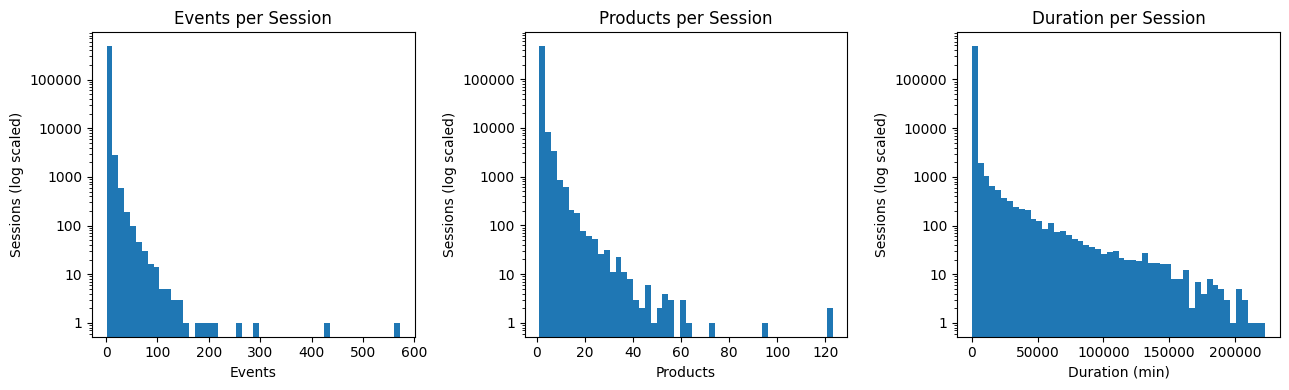

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))

ax[0].hist(session_activity['events'], bins=50)
ax[0].set_title('Events per Session')
ax[0].set_xlabel('Events')
ax[0].set_ylabel('Sessions (log scaled)')
ax[0].set_yscale('log')
ax[0].yaxis.set_major_formatter(ScalarFormatter())  # 10^2 to 100

ax[1].hist(session_activity['products'], bins=50)
ax[1].set_title('Products per Session')
ax[1].set_xlabel('Products')
ax[1].set_ylabel('Sessions (log scaled)')
ax[1].set_yscale('log')
ax[1].yaxis.set_major_formatter(ScalarFormatter())

ax[2].hist(session_duration['duration_minutes'], bins=50)
ax[2].set_title('Duration per Session')
ax[2].set_xlabel('Duration (min)')
ax[2].set_ylabel('Sessions (log scaled)')
ax[2].set_yscale('log')
ax[2].yaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

Session activity is also strongly right-skewed. A typical session contains only **1 event** and **1 unique product**, while the **mean is higher** at **1.80 events** and **1.29 unique products** per session.

**90%** of sessions contain no more than **3 events** and **2 unique products**, while the **top 1%** of sessions contain **11 or more events** and **6 or more unique products**. This indicates that most sessions represent relatively short and simple interactions with the store, while a small number of sessions are much more active.

We also explored session duration, calculated as the time between the first and last recorded event within a `user_session`. The distribution is highly skewed: the **median duration** is **0 minutes**, while **95% of sessions** are shorter than **56.8 minutes**. The very long tail reaches **more than 155 days** (223 240.28 minutes), which indicates that `user_session` does not always correspond to a continuous visit.

Therefore, we will not use session duration as a measure of actual visit duration in the funnel analysis. Instead, we will focus on events and unique products per session.

## Funnel Analysis

For this analysis, the funnel is evaluated at the `user_session` level.

A successful purchase session must contain the following sequence of events:

> View → Cart → Purchase

A session is considered converted only when all three stages are completed in this order.

Sessions with missing `user_session` IDs are excluded from session-level funnel calculations because they cannot be reliably assigned to a specific session.

### Overall Funnel

In [29]:
# missing
df_clear = df[df['user_session'].notna()]

df_clear.isna().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,0


In [30]:
# right order
df_clear = df_clear.sort_values(['user_session', 'event_time'])

df_clear.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
717617,2021-01-31 20:27:14+00:00,view,337112,2144415921505042512,Unknown,Unknown,12.06,1515915625599214495,000AMhYaQu
27197,2020-09-30 17:52:02+00:00,view,1675002,2144415922872385653,electronics.tablet,xiaomi,421.22,1515915625509232600,000c34fa-991f-442a-8e07-8c472269bec6
577627,2021-01-09 23:35:49+00:00,view,40146,2144415925732901052,appliances.kitchen.juicer,Unknown,61.98,1515915625591270059,001HttdHUk
221736,2020-11-06 01:25:30+00:00,view,3605162,2144415924684325027,electronics.audio.headphone,Unknown,18.86,1515915625536141302,001P7lK0Pt
221737,2020-11-06 01:25:43+00:00,view,3585175,2144415924684325027,electronics.audio.headphone,samsung,148.84,1515915625536141302,001P7lK0Pt
519443,2020-12-29 04:50:33+00:00,view,387956,2144415922427789416,computers.components.videocards,asus,104.21,1515915625570256322,001RxUtFJa
9367,2020-09-26 18:59:06+00:00,view,3582066,2144415927284793573,computers.components.tv_tuner,d-color,27.95,1515915625520065148,002DmERG1w
151180,2020-10-25 15:23:25+00:00,view,4099850,2144415922125799520,Unknown,palmexx,62.22,1515915625530388040,003QqC0jk0
200814,2020-11-02 18:11:24+00:00,view,80548,2144415925011480748,stationery.cartrige,cactus,16.05,1515915625533857816,003pEktS1X
200822,2020-11-02 18:12:33+00:00,view,1400332,2144415939330834990,computers.peripherals.printer,Unknown,9.84,1515915625533857816,003pEktS1X


In [31]:
# events order by session
views = df_clear[df_clear['event_type'] == 'view'].groupby('user_session')['event_time'].min().rename('view_time')

carts = df_clear[df_clear['event_type'] == 'cart'].groupby('user_session')['event_time'].min().rename('cart_time')

purchases = df_clear[df_clear['event_type'] == 'purchase'].groupby('user_session')['event_time'].min().rename('purchase_time')

session_funnel = pd.concat([views, carts, purchases], axis=1).reset_index()
session_funnel.head()


,user_session,view_time,cart_time,purchase_time
0,000AMhYaQu,2021-01-31 20:27:14+00:00,NaT,NaT
1,000c34fa-991f-442a-8e07-8c472269bec6,2020-09-30 17:52:02+00:00,NaT,NaT
2,001HttdHUk,2021-01-09 23:35:49+00:00,NaT,NaT
3,001P7lK0Pt,2020-11-06 01:25:30+00:00,NaT,NaT
4,001RxUtFJa,2020-12-29 04:50:33+00:00,NaT,NaT


In [32]:
# check right order
session_funnel['view_to_cart'] = (
    session_funnel['view_time'].notna() &
    session_funnel['cart_time'].notna() &
    (session_funnel['view_time'] < session_funnel['cart_time']))

session_funnel['cart_to_purchase'] = (
    session_funnel['cart_time'].notna() &
    session_funnel['purchase_time'].notna() &
    (session_funnel['cart_time'] < session_funnel['purchase_time']))

session_funnel['successful_purchase'] = (session_funnel['view_to_cart'] & session_funnel['cart_to_purchase'])

session_funnel.head()

,user_session,view_time,cart_time,purchase_time,view_to_cart,cart_to_purchase,successful_purchase
0,000AMhYaQu,2021-01-31 20:27:14+00:00,NaT,NaT,False,False,False
1,000c34fa-991f-442a-8e07-8c472269bec6,2020-09-30 17:52:02+00:00,NaT,NaT,False,False,False
2,001HttdHUk,2021-01-09 23:35:49+00:00,NaT,NaT,False,False,False
3,001P7lK0Pt,2020-11-06 01:25:30+00:00,NaT,NaT,False,False,False
4,001RxUtFJa,2020-12-29 04:50:33+00:00,NaT,NaT,False,False,False


In [33]:
# conv
total_sessions = len(session_funnel)

view_sessions = session_funnel['view_time'].notna().sum()

cart_sessions = session_funnel['view_to_cart'].sum()

purchase_sessions = session_funnel['successful_purchase'].sum()

view_to_cart_rate = cart_sessions / view_sessions * 100

cart_to_purchase_rate = purchase_sessions / cart_sessions * 100

overall_conversion = purchase_sessions / view_sessions * 100

print(f"Total sessions: {total_sessions}")
print(f"View: {view_sessions}")
print(f"View -> Cart: {cart_sessions}")
print(f"View -> Cart -> Purchase: {purchase_sessions}")

print(f"\nView -> Cart: {view_to_cart_rate:.2f}%")
print(f"Cart -> Purchase: {cart_to_purchase_rate:.2f}%")
print(f"View -> Cart -> Purchase: {overall_conversion:.2f}%")

Total sessions: 490398
View: 488360
View -> Cart: 41214
View -> Cart -> Purchase: 20506

View -> Cart: 8.44%
Cart -> Purchase: 49.75%
View -> Cart -> Purchase: 4.20%


In [34]:
funnel_summary = pd.DataFrame({
    'stage' : ['View', 'Cart', 'Purchase'],
    'session' : [view_sessions, cart_sessions, purchase_sessions]})

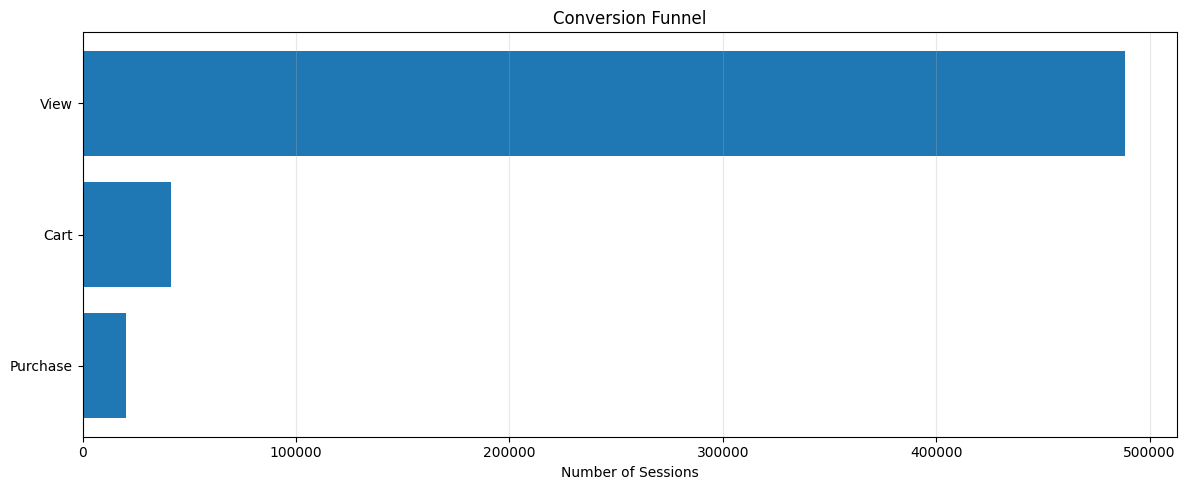

In [35]:
plt.figure(figsize=(12,5))

plt.barh(funnel_summary['stage'], funnel_summary['session'])
plt.title('Conversion Funnel')
plt.xlabel('Number of Sessions')

plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The main drop-off occurs between product view and cart addition. Although almost all recorded sessions contain a product view, only **8.44%** of view sessions progress to the cart.

In contrast, the **Cart → Purchase conversion is 49.75%**, meaning that almost half of the sessions that reach the cart eventually result in a purchase.

Overall, **4.20%** of view sessions progress through the complete **View → Cart → Purchase** funnel.

This suggests that the largest potential conversion **gap is at the View → Cart** stage, rather than at the final purchase stage.

> The funnel conversion rates should be **interpreted with some caution** because of limitations in the `user_session` field and our funnel definition (some `user_session` IDs persist for unusually long periods and the main funnel requires a strict View → Cart → Purchase sequence. Sessions containing a purchase but not following this exact sequence are not counted as successful funnel conversions. Therefore, the 4.20% conversion rate represents completion of the predefined funnel sequence, rather than the overall share of sessions containing a purchase).




These limitations do not invalidate the analysis, but they should be considered when interpreting the absolute conversion rates.

### Drop-off Analysis

In [36]:
funnel_summary['previous_stage_session'] = funnel_summary['session'].shift(1)

funnel_summary['drop_off'] = funnel_summary['previous_stage_session'] - funnel_summary['session']

funnel_summary['drop_off_share'] = round(funnel_summary['drop_off'] / funnel_summary['previous_stage_session'] * 100, 2)

funnel_summary

,stage,session,previous_stage_session,drop_off,drop_off_share
0,View,488360,NaN,NaN,NaN
1,Cart,41214,488360.0,447146.0,91.56
2,Purchase,20506,41214.0,20708.0,50.25


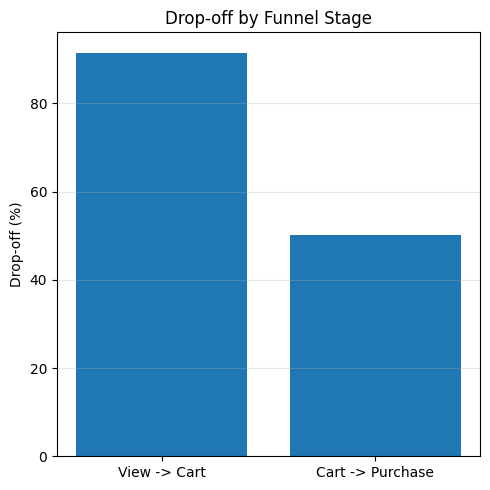

In [37]:
plt.figure(figsize=(5,5))

plt.bar(funnel_summary['stage'], funnel_summary['drop_off_share'])
plt.ylabel('Drop-off (%)')
plt.title('Drop-off by Funnel Stage')

plt.grid(axis='y', alpha=0.3)
plt.xticks(ticks=[1, 2], labels=['View -> Cart', 'Cart -> Purchase'])

plt.tight_layout()
plt.show()

The largest drop-off occurs at the **View → Cart** stage, where **91.56%** of sessions do not proceed to adding a product to the cart.

**Cart → Purchase** stage performs considerably better, but still loses **50.25%** of sessions.

This suggests that the main conversion bottleneck is at the early stage of the funnel - turning product interest into cart additions, rather than completing the purchase after an item has been added to the cart.

### Funnel by Category

To analyze the funnel by product category, the data was aggregated at the **session x category** level.

Each row represents one category interaction within a session. For each session-category pair, we identified the first view, cart, and purchase event and checked their chronological order.

A successful conversion was defined as:

> View → Cart → Purchase

within the same session and for the same product category.

This allows us to compare funnel performance across categories while keeping the analysis consistent with the session-level funnel.

In [38]:
session_category = df_clear[['user_session', 'category_code', 'event_type', 'event_time']].copy()

session_category.head()

,user_session,category_code,event_type,event_time
717617,000AMhYaQu,Unknown,view,2021-01-31 20:27:14+00:00
27197,000c34fa-991f-442a-8e07-8c472269bec6,electronics.tablet,view,2020-09-30 17:52:02+00:00
577627,001HttdHUk,appliances.kitchen.juicer,view,2021-01-09 23:35:49+00:00
221736,001P7lK0Pt,electronics.audio.headphone,view,2020-11-06 01:25:30+00:00
221737,001P7lK0Pt,electronics.audio.headphone,view,2020-11-06 01:25:43+00:00


In [39]:
# events order by session and category
views = session_category[session_category['event_type'] == 'view'].groupby(
    ['user_session', 'category_code'])['event_time'].min().rename('view_time')

carts = session_category[session_category['event_type'] == 'cart'].groupby(
    ['user_session', 'category_code'])['event_time'].min().rename('cart_time')

purchases = session_category[session_category['event_type'] == 'purchase'].groupby(
    ['user_session', 'category_code'])['event_time'].min().rename('purchase_time')

session_category_funnel = pd.concat([views, carts, purchases], axis=1).reset_index()
session_category_funnel.head()

,user_session,category_code,view_time,cart_time,purchase_time
0,000AMhYaQu,Unknown,2021-01-31 20:27:14+00:00,NaT,NaT
1,000c34fa-991f-442a-8e07-8c472269bec6,electronics.tablet,2020-09-30 17:52:02+00:00,NaT,NaT
2,001HttdHUk,appliances.kitchen.juicer,2021-01-09 23:35:49+00:00,NaT,NaT
3,001P7lK0Pt,electronics.audio.headphone,2020-11-06 01:25:30+00:00,NaT,NaT
4,001RxUtFJa,computers.components.videocards,2020-12-29 04:50:33+00:00,NaT,NaT


In [40]:
# check right order
session_category_funnel['view_to_cart'] = (
    session_category_funnel['view_time'].notna() &
    session_category_funnel['cart_time'].notna() &
    (session_category_funnel['view_time'] < session_category_funnel['cart_time']))

session_category_funnel['cart_to_purchase'] = (
    session_category_funnel['cart_time'].notna() &
    session_category_funnel['purchase_time'].notna() &
    (session_category_funnel['cart_time'] < session_category_funnel['purchase_time']))

session_category_funnel['successful_purchase'] = (session_category_funnel['view_to_cart'] & session_category_funnel['cart_to_purchase'])

session_category_funnel.head()

,user_session,category_code,view_time,cart_time,purchase_time,view_to_cart,cart_to_purchase,successful_purchase
0,000AMhYaQu,Unknown,2021-01-31 20:27:14+00:00,NaT,NaT,False,False,False
1,000c34fa-991f-442a-8e07-8c472269bec6,electronics.tablet,2020-09-30 17:52:02+00:00,NaT,NaT,False,False,False
2,001HttdHUk,appliances.kitchen.juicer,2021-01-09 23:35:49+00:00,NaT,NaT,False,False,False
3,001P7lK0Pt,electronics.audio.headphone,2020-11-06 01:25:30+00:00,NaT,NaT,False,False,False
4,001RxUtFJa,computers.components.videocards,2020-12-29 04:50:33+00:00,NaT,NaT,False,False,False


In [41]:
# conv

total_sessions = len(session_category_funnel)

view_sessions = session_category_funnel['view_time'].notna().sum()

cart_sessions = session_category_funnel['view_to_cart'].sum()

purchase_sessions = session_category_funnel['successful_purchase'].sum()


print(f"Total sessions x category pairs: {total_sessions}")
print(f"View: {view_sessions}")
print(f"View -> Cart: {cart_sessions}")
print(f"View -> Cart -> Purchase: {purchase_sessions}")


Total sessions x category pairs: 506606
View: 504332
View -> Cart: 43894
View -> Cart -> Purchase: 21489


In [42]:
# funnel by categories

category_funnel = session_category_funnel.groupby('category_code').agg(
    total_sessions = ('category_code', 'size'),
    view_sessions = ('view_time', 'count'),
    view_to_cart = ('view_to_cart', 'sum'),
    successful_purchase = ('successful_purchase', 'sum')).sort_values('total_sessions', ascending=False).reset_index()

category_funnel

,category_code,total_sessions,view_sessions,view_to_cart,successful_purchase
0,Unknown,149995,149524,8769,4423
1,electronics.telephone,50635,50357,4519,2396
2,computers.components.videocards,44480,44083,9323,3956
3,stationery.cartrige,24446,24261,2339,1379
4,computers.peripherals.printer,23610,23473,2623,1489
...,...,...,...,...,...
103,furniture.bedroom.blanket,17,17,2,0
104,appliances.kitchen.refrigerators,13,13,0,0
105,furniture.kitchen.chair,13,13,0,0
106,accessories.briefcase,8,8,2,0


In [43]:
# conv overall_conversion

category_funnel['view_to_cart_rate'] = round(category_funnel['view_to_cart'] / category_funnel['view_sessions'] * 100, 2)

category_funnel['cart_to_purchase_rate'] = round(category_funnel['successful_purchase'] / category_funnel['view_to_cart'] * 100, 2)

category_funnel['overall_conversion'] = round(category_funnel['successful_purchase'] / category_funnel['view_sessions'] * 100, 2)

category_funnel.head()

,category_code,total_sessions,view_sessions,view_to_cart,successful_purchase,view_to_cart_rate,cart_to_purchase_rate,overall_conversion
0,Unknown,149995,149524,8769,4423,5.86,50.44,2.96
1,electronics.telephone,50635,50357,4519,2396,8.97,53.02,4.76
2,computers.components.videocards,44480,44083,9323,3956,21.15,42.43,8.97
3,stationery.cartrige,24446,24261,2339,1379,9.64,58.96,5.68
4,computers.peripherals.printer,23610,23473,2623,1489,11.17,56.77,6.34


In [44]:
# deleting category with small amount of session
category_funnel_filtered = category_funnel[category_funnel['view_sessions'] >= 100].copy()
category_funnel_filtered.shape

(92, 8)

In [45]:
category_funnel_filtered['view_rate'] = 100.0
category_funnel_filtered.sort_values('overall_conversion', ascending=True).head(10)

,category_code,total_sessions,view_sessions,view_to_cart,successful_purchase,view_to_cart_rate,cart_to_purchase_rate,overall_conversion,view_rate
83,kids.skates,154,154,5,0,3.25,0.00,0.00,100.0
72,electronics.fax,307,307,1,0,0.33,0.00,0.00,100.0
42,appliances.kitchen.juicer,1487,1487,6,2,0.40,33.33,0.13,100.0
68,appliances.personal.scales,449,449,3,2,0.67,66.67,0.45,100.0
67,construction.tools.pump,450,449,7,2,1.56,28.57,0.45,100.0
45,country_yard.cultivator,1329,1329,25,8,1.88,32.00,0.60,100.0
78,computers.gaming,168,168,6,1,3.57,16.67,0.60,100.0
28,appliances.kitchen.coffee_machine,2455,2455,44,15,1.79,34.09,0.61,100.0
80,appliances.kitchen.toster,157,157,1,1,0.64,100.00,0.64,100.0
84,appliances.kitchen.coffee_grinder,153,153,5,1,3.27,20.00,0.65,100.0


In [46]:
top_10 = category_funnel_filtered.sort_values('overall_conversion', ascending=False).head(10)
top_10

,category_code,total_sessions,view_sessions,view_to_cart,successful_purchase,view_to_cart_rate,cart_to_purchase_rate,overall_conversion,view_rate
27,computers.peripherals.camera,2553,2532,512,319,20.22,62.30,12.60,100.0
2,computers.components.videocards,44480,44083,9323,3956,21.15,42.43,8.97,100.0
52,computers.peripherals.scanner,1079,1069,181,90,16.93,49.72,8.42,100.0
33,computers.ebooks,1857,1848,238,131,12.88,55.04,7.09,100.0
58,electronics.video.projector,868,862,100,56,11.60,56.00,6.50,100.0
4,computers.peripherals.printer,23610,23473,2623,1489,11.17,56.77,6.34,100.0
66,stationery.stapler,451,449,43,28,9.58,65.12,6.24,100.0
18,computers.components.power_supply,4473,4437,650,270,14.65,41.54,6.09,100.0
8,computers.components.motherboard,12560,12471,1724,739,13.82,42.87,5.93,100.0
69,computers.components.cdrw,436,434,44,25,10.14,56.82,5.76,100.0


In [47]:
top_10_plot = top_10[['category_code', 'view_rate', 'view_to_cart_rate', 'cart_to_purchase_rate']].melt(
    id_vars='category_code', # dont touch
    var_name='stage',
    value_name='rate')

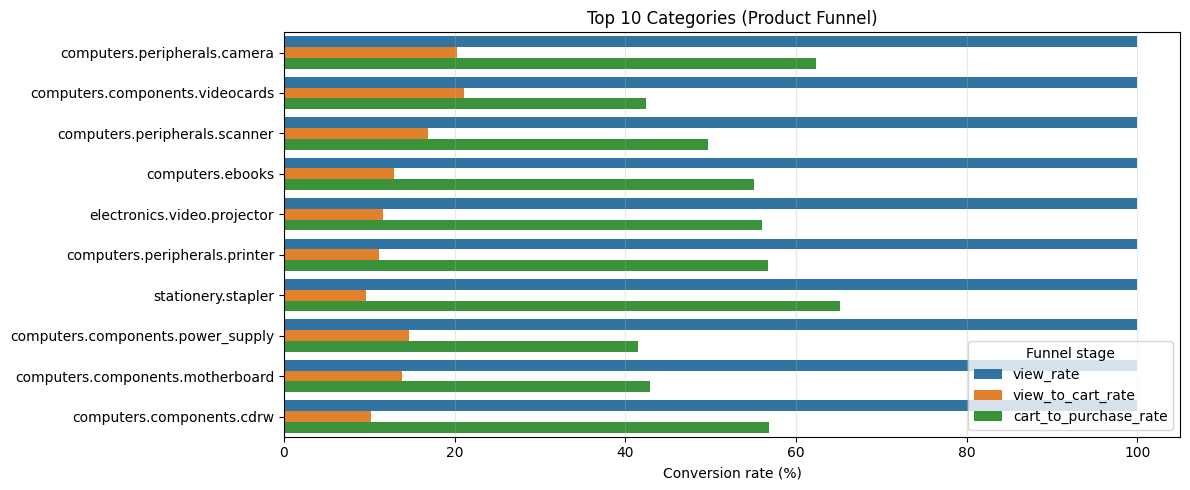

In [48]:
plt.figure(figsize=(12,5))

sns.barplot(data=top_10_plot, x='rate', y='category_code', hue='stage')
plt.xlabel('Conversion rate (%)')
plt.ylabel('')
plt.title('Top 10 Categories (Product Funnel)')
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Funnel stage')

plt.tight_layout()
plt.show()

The category-level funnel reveals substantial differences in conversion performance across product categories. After excluding categories with fewer than 100 product views, the overall View → Cart → Purchase conversion varies considerably, indicating that product category has a strong relationship with funnel performance.

The strongest-performing category is **computers.peripherals.camera**, with an overall conversion of **12.60%**. It combines a strong View → Cart rate of **20.22%** with a high Cart → Purchase rate of **62.30%**, suggesting that users show strong purchase intent at both stages of the funnel. **computers.components.videocards** ranks second with an overall conversion of **8.97%** and has the highest View → Cart rate among the top categories (**21.15%**). However, its Cart → Purchase rate is lower (**42.43%**), indicating that the main opportunity may be reducing drop-off after products are added to the cart.

Other strong-performing categories include **computers.peripherals.scanner (8.42%)**, **computers.ebooks (7.09%)**, and **electronics.video.projector (6.50%)**. These categories maintain relatively strong conversion across both funnel stages rather than relying on a single exceptionally high metric.

The lowest-performing categories show a very different pattern. Categories such as **kids.skates** and **electronics.fax** generated views but almost no progression to Cart, resulting in 0% overall conversion. **appliances.kitchen.juicer** also shows a very low View → Cart rate of 0.40%, despite having a 33.33% Cart → Purchase rate. This suggests that for these categories, the main issue occurs at the View → Cart stage, rather than during the final purchase step.

Overall, the analysis suggests that category performance is driven by different funnel bottlenecks. High-performing categories tend to combine strong product engagement with relatively efficient purchase completion, while low-performing categories often struggle to convert product views into cart additions. This indicates that category-specific optimization strategies may be more effective than applying a single funnel improvement across the entire store.

### Funnel by Brand

To analyze the funnel by product brand, the data was aggregated at the **session x brand** level.

Each row represents one brand interaction within a session. For each session-brand pair, we identified the first view, cart, and purchase event and checked their chronological order.

A successful conversion was defined as:

> View → Cart → Purchase

within the same session and for the same brand.

This allows us to compare funnel performance across brands while keeping the analysis consistent with the session-level funnel.

In [49]:
session_brand = df_clear[['user_session', 'brand', 'event_type', 'event_time']].copy()

session_brand.head()

,user_session,brand,event_type,event_time
717617,000AMhYaQu,Unknown,view,2021-01-31 20:27:14+00:00
27197,000c34fa-991f-442a-8e07-8c472269bec6,xiaomi,view,2020-09-30 17:52:02+00:00
577627,001HttdHUk,Unknown,view,2021-01-09 23:35:49+00:00
221736,001P7lK0Pt,Unknown,view,2020-11-06 01:25:30+00:00
221737,001P7lK0Pt,samsung,view,2020-11-06 01:25:43+00:00


In [50]:
# events order by session and brand
views = session_brand[session_brand['event_type'] == 'view'].groupby(
    ['user_session', 'brand'])['event_time'].min().rename('view_time')

carts = session_brand[session_brand['event_type'] == 'cart'].groupby(
    ['user_session', 'brand'])['event_time'].min().rename('cart_time')

purchases = session_brand[session_brand['event_type'] == 'purchase'].groupby(
    ['user_session', 'brand'])['event_time'].min().rename('purchase_time')

session_brand_funnel = pd.concat([views, carts, purchases], axis=1).reset_index()
session_brand_funnel.head()

,user_session,brand,view_time,cart_time,purchase_time
0,000AMhYaQu,Unknown,2021-01-31 20:27:14+00:00,NaT,NaT
1,000c34fa-991f-442a-8e07-8c472269bec6,xiaomi,2020-09-30 17:52:02+00:00,NaT,NaT
2,001HttdHUk,Unknown,2021-01-09 23:35:49+00:00,NaT,NaT
3,001P7lK0Pt,Unknown,2020-11-06 01:25:30+00:00,NaT,NaT
4,001P7lK0Pt,samsung,2020-11-06 01:25:43+00:00,NaT,NaT


In [51]:
# check right order
session_brand_funnel['view_to_cart'] = (
    session_brand_funnel['view_time'].notna() &
    session_brand_funnel['cart_time'].notna() &
    (session_brand_funnel['view_time'] < session_brand_funnel['cart_time']))

session_brand_funnel['cart_to_purchase'] = (
    session_brand_funnel['cart_time'].notna() &
    session_brand_funnel['purchase_time'].notna() &
    (session_brand_funnel['cart_time'] < session_brand_funnel['purchase_time']))

session_brand_funnel['successful_purchase'] = (session_brand_funnel['view_to_cart'] & session_brand_funnel['cart_to_purchase'])

session_brand_funnel.head()

,user_session,brand,view_time,cart_time,purchase_time,view_to_cart,cart_to_purchase,successful_purchase
0,000AMhYaQu,Unknown,2021-01-31 20:27:14+00:00,NaT,NaT,False,False,False
1,000c34fa-991f-442a-8e07-8c472269bec6,xiaomi,2020-09-30 17:52:02+00:00,NaT,NaT,False,False,False
2,001HttdHUk,Unknown,2021-01-09 23:35:49+00:00,NaT,NaT,False,False,False
3,001P7lK0Pt,Unknown,2020-11-06 01:25:30+00:00,NaT,NaT,False,False,False
4,001P7lK0Pt,samsung,2020-11-06 01:25:43+00:00,NaT,NaT,False,False,False


In [52]:
# conv

total_sessions = len(session_brand_funnel)

view_sessions = session_brand_funnel['view_time'].notna().sum()

cart_sessions = session_brand_funnel['view_to_cart'].sum()

purchase_sessions = session_brand_funnel['successful_purchase'].sum()


print(f"Total sessions x brand pairs: {total_sessions}")
print(f"View: {view_sessions}")
print(f"View -> Cart: {cart_sessions}")
print(f"View -> Cart -> Purchase: {purchase_sessions}")

Total sessions x brand pairs: 565648
View: 563261
View -> Cart: 46059
View -> Cart -> Purchase: 21998


In [53]:
# funnel by brands

brand_funnel = session_brand_funnel.groupby('brand').agg(
    total_sessions = ('brand', 'size'),
    view_sessions = ('view_time', 'count'),
    view_to_cart = ('view_to_cart', 'sum'),
    successful_purchase = ('successful_purchase', 'sum')).sort_values('total_sessions', ascending=False).reset_index()

brand_funnel

,brand,total_sessions,view_sessions,view_to_cart,successful_purchase
0,Unknown,137805,137188,10727,5489
1,samsung,15864,15815,883,455
2,asus,15022,14944,1766,779
3,palit,14130,14016,1976,693
4,gigabyte,12757,12665,2638,1098
...,...,...,...,...,...
995,cassida,1,1,0,0
996,bento,1,1,0,0
997,wietus,1,1,0,0
998,beward,1,1,0,0


In [54]:
# conv
brand_funnel['view_rate'] = 100.0

brand_funnel['view_to_cart_rate'] = round(brand_funnel['view_to_cart'] / brand_funnel['view_sessions'] * 100, 2)

brand_funnel['cart_to_purchase_rate'] = round(brand_funnel['successful_purchase'] / brand_funnel['view_to_cart'] * 100, 2)

brand_funnel['overall_conversion'] = round(brand_funnel['successful_purchase'] / brand_funnel['view_sessions'] * 100, 2)

brand_funnel.head()


,brand,total_sessions,view_sessions,view_to_cart,successful_purchase,view_rate,view_to_cart_rate,cart_to_purchase_rate,overall_conversion
0,Unknown,137805,137188,10727,5489,100.0,7.82,51.17,4.00
1,samsung,15864,15815,883,455,100.0,5.58,51.53,2.88
2,asus,15022,14944,1766,779,100.0,11.82,44.11,5.21
3,palit,14130,14016,1976,693,100.0,14.10,35.07,4.94
4,gigabyte,12757,12665,2638,1098,100.0,20.83,41.62,8.67


In [55]:
# deleting brands with small amount of session
brand_funnel_filtered = brand_funnel[brand_funnel['view_sessions'] >= 100].copy()

In [56]:
#bottom
brand_funnel_filtered.sort_values('overall_conversion', ascending=True).head(10)

,brand,total_sessions,view_sessions,view_to_cart,successful_purchase,view_rate,view_to_cart_rate,cart_to_purchase_rate,overall_conversion
374,mallony,101,101,1,0,100.0,0.99,0.0,0.0
344,htc,120,120,1,0,100.0,0.83,0.0,0.0
342,ultraflash,122,122,1,0,100.0,0.82,0.0,0.0
340,gardena,123,123,1,0,100.0,0.81,0.0,0.0
353,piquadro,113,113,1,0,100.0,0.88,0.0,0.0
349,flexis,116,116,1,0,100.0,0.86,0.0,0.0
347,willmark,117,117,0,0,100.0,0.00,NaN,0.0
346,sumdex,117,117,0,0,100.0,0.00,NaN,0.0
352,audio-technica,114,114,2,0,100.0,1.75,0.0,0.0
335,soundmax,125,125,3,0,100.0,2.40,0.0,0.0


In [57]:
top_10 = brand_funnel_filtered.sort_values('overall_conversion', ascending=False).head(10)
top_10

,brand,total_sessions,view_sessions,view_to_cart,successful_purchase,view_rate,view_to_cart_rate,cart_to_purchase_rate,overall_conversion
253,codyson,241,231,55,38,100.0,23.81,69.09,16.45
170,keenetic,463,458,79,59,100.0,17.25,74.68,12.88
199,canyon,349,348,60,43,100.0,17.24,71.67,12.36
20,sapphire,4697,4641,1190,570,100.0,25.64,47.90,12.28
337,content,124,123,25,15,100.0,20.33,60.00,12.20
95,steelseries,911,903,191,105,100.0,21.15,54.97,11.63
163,saitek,495,490,110,52,100.0,22.45,47.27,10.61
6,msi,10555,10455,2459,1088,100.0,23.52,44.25,10.41
46,nv-print,2150,2123,329,202,100.0,15.50,61.40,9.51
187,p.i.t,389,385,59,35,100.0,15.32,59.32,9.09


In [58]:
top_10_plot = top_10[['brand', 'view_rate', 'view_to_cart_rate', 'cart_to_purchase_rate']].melt(
    id_vars='brand',
    var_name='stage',
    value_name='rate')

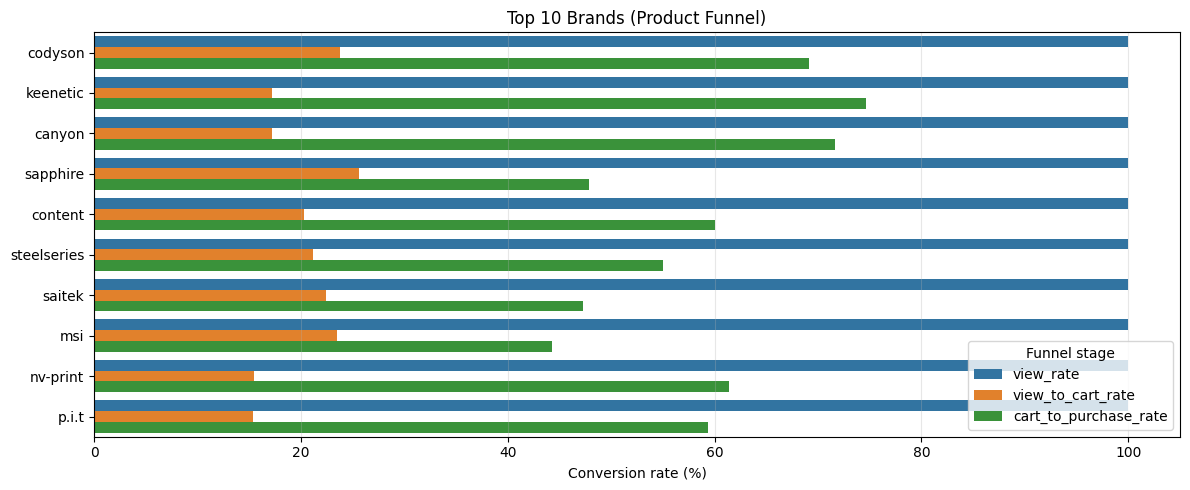

In [59]:
plt.figure(figsize=(12,5))

sns.barplot(data=top_10_plot, x='rate', y='brand', hue='stage')
plt.xlabel('Conversion rate (%)')
plt.ylabel('')
plt.title('Top 10 Brands (Product Funnel)')
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Funnel stage')

plt.tight_layout()
plt.show()

The brand-level funnel shows substantial differences in conversion performance across brands. The strongest-performing brand is **codyson**, with an overall View → Cart → Purchase conversion of **16.45%**. It combines a strong View → Cart rate of **23.81%** with a high Cart → Purchase rate of **69.09%**, indicating strong performance throughout the entire funnel.

Other high-performing brands include **keenetic (12.88%)**, **canyon (12.36%)** and **sapphire (12.28%)**. These brands maintain relatively high conversion at both funnel stages. In particular, **keenetic** has the highest Cart → Purchase rate among the top brands at **74.68%**, suggesting that users who add these products to the cart have a high probability of completing the purchase.

**sapphire** is particularly notable because of its large volume: it generated **4,641 product views, 1,190 cart additions and 570 successful purchases**. Despite having a lower Cart → Purchase rate than some smaller top-performing brands, its combination of high traffic and strong conversion makes it one of the most commercially significant brands in the analysis.

The lower-performing brands show a different pattern. Brands such as **mallony, htc, ultraflash, gardena, piguadro, and flexis** have almost no View → Cart activity, resulting in **0% overall conversion**. However, these results should be interpreted with caution because the number of cart additions is extremely small.

Overall, the analysis suggests that strong brand performance is driven by two factors: the ability to convert product views into cart additions and the ability to convert carts into purchases. High-performing brands such as codyson and keenetic perform well at both stages, while low-performing brands primarily struggle to move users from product view to cart. This indicates that brand-specific optimization opportunities may exist at different stages of the funnel.

### Funnel by Price Segment

To analyze the funnel by price segment, the data was aggregated at the **session x price segment** level.

Product prices were divided into four segments based on quartiles, creating four groups with approximately equal numbers of observations: **Low, Lower-Mid, Upper-Mid, and High** price segments.

For each session-price segment pair, we identified the first view, cart, and purchase event and checked their chronological order.

A successful conversion was defined as:

> View → Cart → Purchase

within the same session and for the same price segment.

This allows us to compare funnel performance across different price levels while keeping the analysis consistent with the session-level funnel.


In [60]:
session_price = df_clear[['user_session', 'price', 'event_type', 'event_time']].copy()
session_price.head()

,user_session,price,event_type,event_time
717617,000AMhYaQu,12.06,view,2021-01-31 20:27:14+00:00
27197,000c34fa-991f-442a-8e07-8c472269bec6,421.22,view,2020-09-30 17:52:02+00:00
577627,001HttdHUk,61.98,view,2021-01-09 23:35:49+00:00
221736,001P7lK0Pt,18.86,view,2020-11-06 01:25:30+00:00
221737,001P7lK0Pt,148.84,view,2020-11-06 01:25:43+00:00


In [61]:
# segmentation
q1 = session_price['price'].quantile(0.25)
q2 = session_price['price'].quantile(0.50)
q3 = session_price['price'].quantile(0.75)

session_price['price_segment'] = pd.cut(session_price['price'],
    bins=[0, q1, q2, q3, session_price['price'].max()],
    labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High'])

session_price['price_segment'].value_counts()

,count
price_segment,
Low,222368
High,220985
Upper-Mid,220974
Lower-Mid,219985


In [62]:
# events order by session and price segment
# observed=True - silence this warning
views = session_price[session_price['event_type'] == 'view'].groupby(
    ['user_session', 'price_segment'], observed=True)['event_time'].min().rename('view_time')

carts = session_price[session_price['event_type'] == 'cart'].groupby(
    ['user_session', 'price_segment'], observed=True)['event_time'].min().rename('cart_time')

purchases = session_price[session_price['event_type'] == 'purchase'].groupby(
    ['user_session', 'price_segment'], observed=True)['event_time'].min().rename('purchase_time')

session_price_funnel = pd.concat([views, carts, purchases], axis=1).reset_index()
session_price_funnel.head()

,user_session,price_segment,view_time,cart_time,purchase_time
0,000AMhYaQu,Low,2021-01-31 20:27:14+00:00,NaT,NaT
1,000c34fa-991f-442a-8e07-8c472269bec6,High,2020-09-30 17:52:02+00:00,NaT,NaT
2,001HttdHUk,Lower-Mid,2021-01-09 23:35:49+00:00,NaT,NaT
3,001P7lK0Pt,Low,2020-11-06 01:25:30+00:00,NaT,NaT
4,001P7lK0Pt,Upper-Mid,2020-11-06 01:25:43+00:00,NaT,NaT


In [63]:
# check right order
session_price_funnel['view_to_cart'] = (
    session_price_funnel['view_time'].notna() &
    session_price_funnel['cart_time'].notna() &
    (session_price_funnel['view_time'] < session_price_funnel['cart_time']))

session_price_funnel['cart_to_purchase'] = (
    session_price_funnel['cart_time'].notna() &
    session_price_funnel['purchase_time'].notna() &
    (session_price_funnel['cart_time'] < session_price_funnel['purchase_time']))

session_price_funnel['successful_purchase'] = (session_price_funnel['view_to_cart'] & session_price_funnel['cart_to_purchase'])

session_price_funnel.head()

,user_session,price_segment,view_time,cart_time,purchase_time,view_to_cart,cart_to_purchase,successful_purchase
0,000AMhYaQu,Low,2021-01-31 20:27:14+00:00,NaT,NaT,False,False,False
1,000c34fa-991f-442a-8e07-8c472269bec6,High,2020-09-30 17:52:02+00:00,NaT,NaT,False,False,False
2,001HttdHUk,Lower-Mid,2021-01-09 23:35:49+00:00,NaT,NaT,False,False,False
3,001P7lK0Pt,Low,2020-11-06 01:25:30+00:00,NaT,NaT,False,False,False
4,001P7lK0Pt,Upper-Mid,2020-11-06 01:25:43+00:00,NaT,NaT,False,False,False


In [64]:
# conv
total_sessions = len(session_price_funnel)

view_sessions = session_price_funnel['view_time'].notna().sum()

cart_sessions = session_price_funnel['view_to_cart'].sum()

purchase_sessions = session_price_funnel['successful_purchase'].sum()


print(f"Total sessions x price segment pairs: {total_sessions}")
print(f"View: {view_sessions}")
print(f"View -> Cart: {cart_sessions}")
print(f"View -> Cart -> Purchase: {purchase_sessions}")

Total sessions x price segment pairs: 524198
View: 521992
View -> Cart: 43081
View -> Cart -> Purchase: 21210


In [65]:
# funnel by price segment

price_segment_funnel = session_price_funnel.groupby('price_segment', observed=True).agg(
    total_sessions = ('price_segment', 'size'),
    view_sessions = ('view_time', 'count'),
    view_to_cart = ('view_to_cart', 'sum'),
    successful_purchase = ('successful_purchase', 'sum')).sort_values('total_sessions', ascending=False).reset_index()

price_segment_funnel

,price_segment,total_sessions,view_sessions,view_to_cart,successful_purchase
0,Low,146732,146159,9934,5454
1,Lower-Mid,137385,136775,10180,5332
2,Upper-Mid,128478,128022,9700,4703
3,High,111603,111036,13267,5721


In [66]:
# conv
price_segment_funnel['view_rate'] = 100.0

price_segment_funnel['view_to_cart_rate'] = round(price_segment_funnel['view_to_cart'] / price_segment_funnel['view_sessions'] * 100, 2)

price_segment_funnel['cart_to_purchase_rate'] = round(price_segment_funnel['successful_purchase'] / price_segment_funnel['view_to_cart'] * 100, 2)

price_segment_funnel['overall_conversion'] = round(price_segment_funnel['successful_purchase'] / price_segment_funnel['view_sessions'] * 100, 2)

price_segment_funnel.head()

,price_segment,total_sessions,view_sessions,view_to_cart,successful_purchase,view_rate,view_to_cart_rate,cart_to_purchase_rate,overall_conversion
0,Low,146732,146159,9934,5454,100.0,6.80,54.90,3.73
1,Lower-Mid,137385,136775,10180,5332,100.0,7.44,52.38,3.90
2,Upper-Mid,128478,128022,9700,4703,100.0,7.58,48.48,3.67
3,High,111603,111036,13267,5721,100.0,11.95,43.12,5.15


In [67]:
price_segment_plot = price_segment_funnel[['price_segment', 'view_rate', 'view_to_cart_rate', 'cart_to_purchase_rate']].melt(
    id_vars='price_segment',
    var_name='stage',
    value_name='rate')

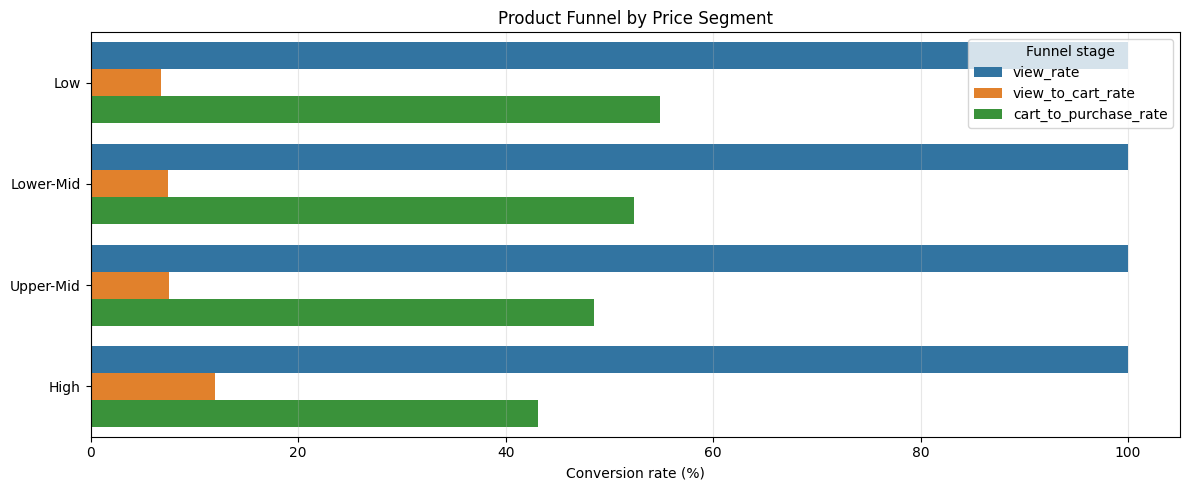

In [68]:
plt.figure(figsize=(12,5))

sns.barplot(data=price_segment_plot, x='rate', y='price_segment', hue='stage')
plt.xlabel('Conversion rate (%)')
plt.ylabel('')
plt.title('Product Funnel by Price Segment')
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Funnel stage')

plt.tight_layout()
plt.show()

The **High-price segment** demonstrates the strongest View → Cart conversion at **11.95%**, compared with **6.80%** for **Low-price products** and **7.44%–7.58%** for the two middle segments. This suggests that higher-priced products generate relatively strong purchase intent at the product-view stage.

However, the **High-price segment** has the lowest Cart → Purchase conversion (**43.12%**). In other words, users are more likely to add high-priced products to their carts, but they are less likely to complete the purchase after doing so. Despite this drop-off, the segment still achieves the highest overall conversion of **5.15%**.

The **Lower-Mid price segment** has the highest overall conversion among the three lower price groups at **3.90%**, followed by **Low** (**3.73%**) and **Upper-Mid** (**3.67%**). This suggests that simply increasing product price does not consistently reduce conversion.

Overall, the analysis indicates that price affects different stages of the funnel differently. Higher-priced products attract stronger engagement and cart additions, but the larger drop-off occurs between Cart and Purchase. This may indicate greater purchase hesitation for expensive products and suggests that high-price products could benefit from strategies focused on reducing purchase friction at the final stage.

## Time Analysis

### Conversion by Hour

To analyze conversion by hour, the data was aggregated at the session level.

For each session, we identified the first view event and used its timestamp to determine the hour when the session started.

Each session was then assigned to one of 24 hourly time periods, from **00:00 to 23:00**.

A successful conversion was defined as:

> View → Cart → Purchase

within the same session and in the correct order.

For each hour, we calculated the total number of sessions, successful conversions, and the resulting conversion rate.

This allows us to identify time-of-day patterns in session conversion while keeping the analysis consistent with the overall session-level funnel.

In [69]:
# session start point
session_start = df_clear[df_clear['event_type'] == 'view'].groupby('user_session')['event_time'].min().reset_index()

# transform to 0-23 hour
session_start['hour'] = session_start['event_time'].dt.hour

session_start.head()

,user_session,event_time,hour
0,000AMhYaQu,2021-01-31 20:27:14+00:00,20
1,000c34fa-991f-442a-8e07-8c472269bec6,2020-09-30 17:52:02+00:00,17
2,001HttdHUk,2021-01-09 23:35:49+00:00,23
3,001P7lK0Pt,2020-11-06 01:25:30+00:00,1
4,001RxUtFJa,2020-12-29 04:50:33+00:00,4


In [70]:
# successful sessions from 'Overall Funnel'
successful_sessions = session_funnel[session_funnel['successful_purchase'] == True]['user_session']

# add succession status for full conversion chain
session_start['successful_purchase'] = session_start['user_session'].isin(successful_sessions)
session_start.head()

,user_session,event_time,hour,successful_purchase
0,000AMhYaQu,2021-01-31 20:27:14+00:00,20,False
1,000c34fa-991f-442a-8e07-8c472269bec6,2020-09-30 17:52:02+00:00,17,False
2,001HttdHUk,2021-01-09 23:35:49+00:00,23,False
3,001P7lK0Pt,2020-11-06 01:25:30+00:00,1,False
4,001RxUtFJa,2020-12-29 04:50:33+00:00,4,False


In [71]:
# conversion by hour
hourly_conversion = (session_start.groupby('hour').agg(
        sessions=('user_session', 'count'),
        purchases=('successful_purchase', 'sum')).reset_index())

hourly_conversion['conversion'] = round(hourly_conversion['purchases'] / hourly_conversion['sessions'] * 100, 2)

hourly_conversion

,hour,sessions,purchases,conversion
0,0,5859,183,3.12
1,1,5987,179,2.99
2,2,6568,234,3.56
3,3,8855,343,3.87
4,4,12363,495,4.00
5,5,16917,757,4.47
6,6,22291,988,4.43
7,7,26159,1168,4.47
8,8,27960,1254,4.48
9,9,29051,1339,4.61


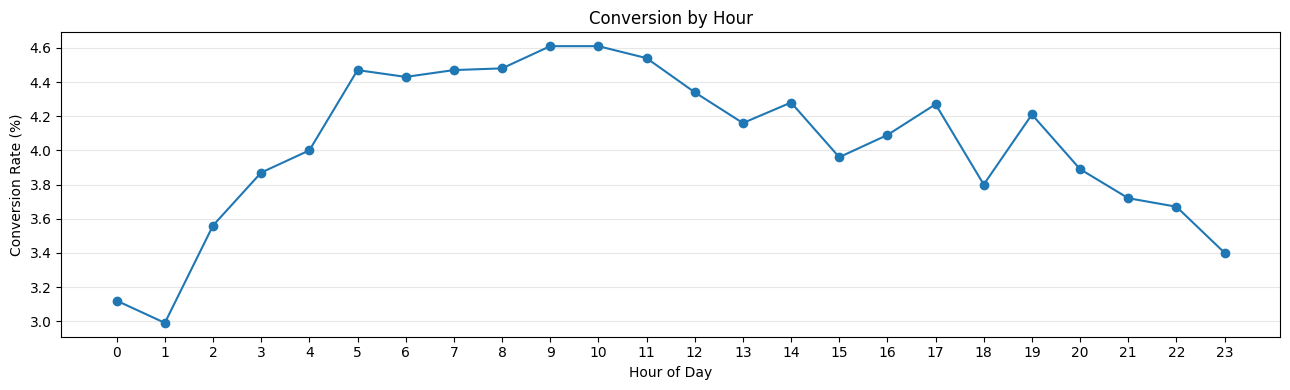

In [72]:
plt.figure(figsize=(13, 4))

plt.plot(hourly_conversion['hour'], hourly_conversion['conversion'], marker='o')

plt.title('Conversion by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Conversion Rate (%)')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Conversion varies noticeably throughout the day, with the lowest rates observed during the late-night and early-morning hours. Conversion increases during the morning and reaches its highest level around 09:00–10:00 (4.61%), before gradually declining later in the day. This suggests that session start time may be associated with different levels of purchase intent.

### Conversion by Weekday

To analyze conversion by day of week, the data was aggregated at the session level.

For each session, we identified the first view event and used its timestamp to determine the day of the week when the session started.

Each session was assigned to one of seven days, **from Monday to Sunday**.

A successful conversion was defined as:

> View → Cart → Purchase

within the same session and in the correct order.

For each day of the week, we calculated the total number of sessions, successful conversions, and the resulting conversion rate.

This allows us to identify potential weekly patterns in session conversion while keeping the analysis consistent with the overall session-level funnel.

In [73]:
# session start point from 'Conversion by Hour'
session_start

# transform to weekday
session_start['day_of_week'] = session_start['event_time'].dt.day_name()

session_start.head()

,user_session,event_time,hour,successful_purchase,day_of_week
0,000AMhYaQu,2021-01-31 20:27:14+00:00,20,False,Sunday
1,000c34fa-991f-442a-8e07-8c472269bec6,2020-09-30 17:52:02+00:00,17,False,Wednesday
2,001HttdHUk,2021-01-09 23:35:49+00:00,23,False,Saturday
3,001P7lK0Pt,2020-11-06 01:25:30+00:00,1,False,Friday
4,001RxUtFJa,2020-12-29 04:50:33+00:00,4,False,Tuesday


In [74]:
# conversion by hour
daily_conversion = (session_start.groupby('day_of_week').agg(
        sessions=('user_session', 'count'),
        purchases=('successful_purchase', 'sum')).reset_index())

daily_conversion['conversion'] = round(daily_conversion['purchases'] / daily_conversion['sessions'] * 100, 2)

daily_conversion

,day_of_week,sessions,purchases,conversion
0,Friday,70228,2880,4.10
1,Monday,73415,3164,4.31
2,Saturday,64504,2686,4.16
3,Sunday,67449,2702,4.01
4,Thursday,70208,2945,4.19
5,Tuesday,71620,3115,4.35
6,Wednesday,70936,3014,4.25


In [75]:
# right day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_conversion['day_of_week'] = pd.Categorical(daily_conversion['day_of_week'], categories=day_order, ordered=True)

daily_conversion = daily_conversion.sort_values('day_of_week')

daily_conversion

,day_of_week,sessions,purchases,conversion
1,Monday,73415,3164,4.31
5,Tuesday,71620,3115,4.35
6,Wednesday,70936,3014,4.25
4,Thursday,70208,2945,4.19
0,Friday,70228,2880,4.10
2,Saturday,64504,2686,4.16
3,Sunday,67449,2702,4.01


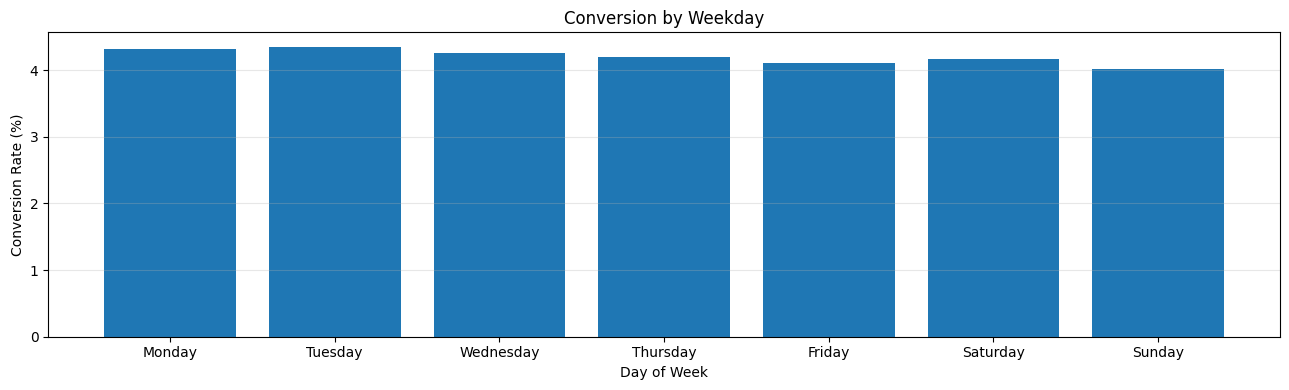

In [76]:
plt.figure(figsize=(13, 4))

plt.bar(daily_conversion['day_of_week'], daily_conversion['conversion'])

plt.title('Conversion by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Conversion Rate (%)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Conversion varies only slightly across the days of the week, ranging from 4.01% on Sunday to 4.35% on Tuesday. The small difference of 0.34 percentage points suggests that day of week has a relatively weak association with session conversion compared with the stronger variation observed by hour. No pronounced weekly pattern is observed.

### Conversion Day x Hour

To analyze how conversion varies across different time periods, the data was aggregated at the session level.

For each session, we identified the first view event and used its timestamp to determine both the hour of day and the day of the week when the session started.

Each session was assigned to **one of 24 hourly periods** and **one of 7 days** of the week.

A successful conversion was defined as:

View → Cart → Purchase

within the same session and in the correct chronological order.

Conversion rate was then calculated for each day-of-week x hour combination as the number of successful sessions divided by the total number of sessions in that time period.

This allows us to identify potential time-based patterns in session conversion and compare conversion performance across different combinations of day and hour.

In [77]:
# conversion by day and hour
day_hour = (session_start.groupby(['day_of_week', 'hour']).agg(
    sessions=('user_session', 'count'),
    purchases=('successful_purchase', 'sum')).reset_index())

day_hour['conversion'] = round(day_hour['purchases'] / day_hour['sessions'] * 100, 2)

day_hour.head()

,day_of_week,hour,sessions,purchases,conversion
0,Friday,0,876,32,3.65
1,Friday,1,890,29,3.26
2,Friday,2,968,33,3.41
3,Friday,3,1407,44,3.13
4,Friday,4,1909,77,4.03


In [78]:
pivot = day_hour.pivot(index='day_of_week', columns='hour', values='conversion')

# right day order
pivot = pivot.reindex(day_order)

pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,2.34,2.32,3.09,4.54,4.76,4.94,4.74,4.81,4.37,4.82,...,4.80,3.60,3.99,4.18,3.95,4.10,4.62,3.58,4.87,3.50
Tuesday,2.59,3.27,4.25,3.66,4.08,4.04,4.54,4.63,4.71,4.90,...,4.45,4.37,4.75,4.41,4.29,4.32,3.66,3.55,3.55,3.94
Wednesday,4.02,3.35,3.95,4.70,3.55,4.62,4.38,4.66,4.50,4.53,...,4.54,3.94,3.90,4.01,3.87,4.29,3.92,3.15,3.41,3.25
Thursday,3.72,2.75,3.64,4.09,3.90,4.96,4.28,4.38,4.71,4.88,...,3.92,4.10,3.65,4.26,3.95,4.08,3.54,4.69,3.36,2.58
Friday,3.65,3.26,3.41,3.13,4.03,3.97,4.54,4.14,4.24,4.08,...,4.06,4.12,3.76,3.78,3.51,4.71,3.90,4.03,3.62,3.41
Saturday,2.77,2.41,2.85,4.16,3.87,4.85,4.22,4.44,4.12,4.62,...,4.30,4.25,4.50,4.85,3.61,4.19,3.42,3.63,3.70,3.68
Sunday,2.84,3.62,3.70,2.76,3.74,3.88,4.22,4.14,4.72,4.44,...,3.86,3.36,4.05,4.41,3.43,3.81,4.16,3.40,3.24,3.43


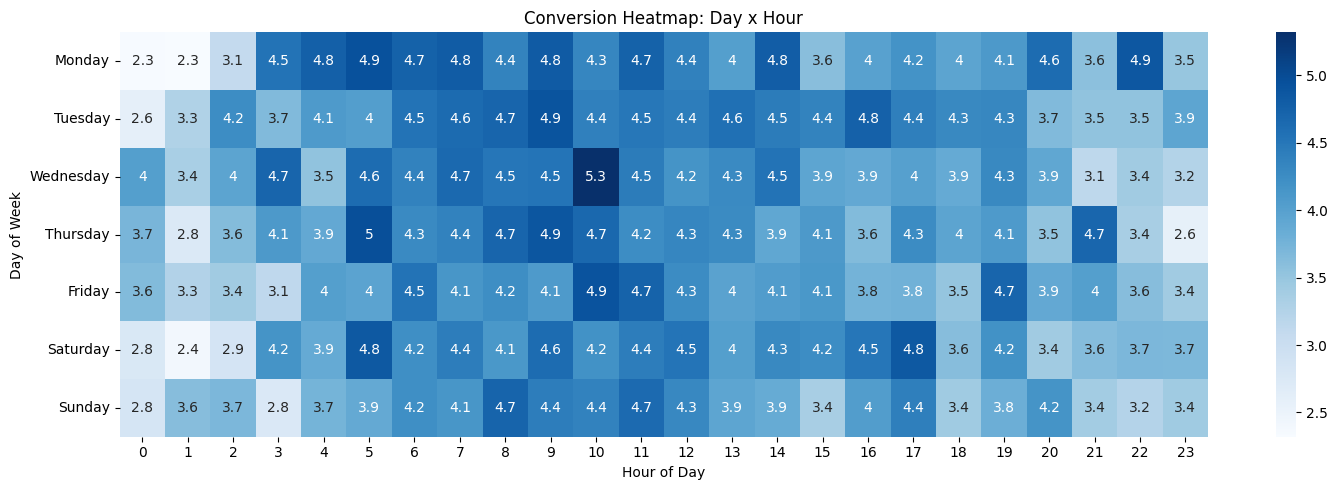

In [79]:
plt.figure(figsize=(15, 5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='Blues')

plt.title('Conversion Heatmap: Day x Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

Conversion varies across both day of week and hour of day, with higher conversion generally observed during morning and daytime hours and lower rates more frequently appearing during late-night periods. The heatmap also shows that conversion patterns depend on the combination of day and hour rather than a single consistently high-performing period. These patterns may indicate differences in user purchase intent throughout the week and day.

## Time-to-Conversion Analysis

To analyze the time required for users to move through the product funnel, the analysis focuses on sessions with a successful chronological order:

> View → Cart → Purchase

For each successfully converted session, we calculated the time spent between the first view and cart event (View → Cart) and between the cart and purchase events (Cart → Purchase).

This allows us to examine how quickly users progress through the funnel and identify whether longer decision times are associated with lower conversion.

In [80]:
# list of needed col
selected_cols = ['user_session', 'view_time', 'cart_time', 'purchase_time']

# session_funnel from 'Overall Funnel'. only successful purchases
time_conversion = session_funnel[session_funnel['successful_purchase']][selected_cols].copy()

time_conversion

,user_session,view_time,cart_time,purchase_time
40,00IohNoWif,2021-02-20 08:55:48+00:00,2021-02-20 09:05:32+00:00,2021-02-20 09:06:30+00:00
46,00Mn72iK5R,2021-01-19 03:59:18+00:00,2021-01-19 04:00:45+00:00,2021-01-19 04:04:12+00:00
56,00RLUrffvt,2020-11-10 18:18:45+00:00,2020-11-10 19:02:50+00:00,2020-11-10 19:03:56+00:00
106,00p2pT8yws,2021-02-11 09:26:39+00:00,2021-02-11 09:32:24+00:00,2021-02-11 09:33:39+00:00
119,00vYeVFh6D,2020-11-28 18:59:01+00:00,2020-11-28 19:00:17+00:00,2020-11-28 19:11:33+00:00
...,...,...,...,...
488287,zzMmWJ9t9Y,2021-02-08 08:53:00+00:00,2021-02-08 08:54:25+00:00,2021-02-08 08:55:00+00:00
488296,zzS1Y8qulW,2020-12-03 07:48:25+00:00,2020-12-03 07:54:38+00:00,2020-12-03 07:56:11+00:00
488304,zzXAlEAqKu,2020-10-17 14:40:08+00:00,2020-10-17 14:40:19+00:00,2020-10-17 14:41:13+00:00
488325,zzfih3qogN,2020-11-12 08:19:48+00:00,2020-11-12 08:21:36+00:00,2020-11-12 08:22:17+00:00


In [81]:
# time between stages
time_conversion['view_to_cart_min'] = round((time_conversion['cart_time'] - time_conversion['view_time']).dt.total_seconds() / 60, 2)

time_conversion['cart_to_purchase_min'] = round((time_conversion['purchase_time'] - time_conversion['cart_time']).dt.total_seconds() / 60, 2)

time_conversion.head()

,user_session,view_time,cart_time,purchase_time,view_to_cart_min,cart_to_purchase_min
40,00IohNoWif,2021-02-20 08:55:48+00:00,2021-02-20 09:05:32+00:00,2021-02-20 09:06:30+00:00,9.73,0.97
46,00Mn72iK5R,2021-01-19 03:59:18+00:00,2021-01-19 04:00:45+00:00,2021-01-19 04:04:12+00:00,1.45,3.45
56,00RLUrffvt,2020-11-10 18:18:45+00:00,2020-11-10 19:02:50+00:00,2020-11-10 19:03:56+00:00,44.08,1.10
106,00p2pT8yws,2021-02-11 09:26:39+00:00,2021-02-11 09:32:24+00:00,2021-02-11 09:33:39+00:00,5.75,1.25
119,00vYeVFh6D,2020-11-28 18:59:01+00:00,2020-11-28 19:00:17+00:00,2020-11-28 19:11:33+00:00,1.27,11.27


In [82]:
# checking distribution before segmentation
time_conversion[['view_to_cart_min', 'cart_to_purchase_min']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
view_to_cart_min,20506.0,387.485247,4401.826908,0.02,0.48,1.33,5.07,26.865,137.2275,8299.335,158112.43
cart_to_purchase_min,20506.0,155.213333,2507.323866,0.07,0.93,1.62,3.78,12.620,38.8425,1607.505,156863.87


In [83]:
#segmentation
bins = [0, 1, 5, 15, 30, 60, float('inf')]

labels = ['< 1 min', '1–5 min', '5–15 min', '15–30 min', '30–60 min', '60+ min']

time_conversion['view_to_cart_group'] = pd.cut(
    time_conversion['view_to_cart_min'],
    bins=bins,
    labels=labels,
    right=False)   # [0, 1) instead of (0, 1]

time_conversion['cart_to_purchase_group'] = pd.cut(
    time_conversion['cart_to_purchase_min'],
    bins=bins,
    labels=labels,
    right=False)

time_conversion.head(10)

,user_session,view_time,cart_time,purchase_time,view_to_cart_min,cart_to_purchase_min,view_to_cart_group,cart_to_purchase_group
40,00IohNoWif,2021-02-20 08:55:48+00:00,2021-02-20 09:05:32+00:00,2021-02-20 09:06:30+00:00,9.73,0.97,5–15 min,< 1 min
46,00Mn72iK5R,2021-01-19 03:59:18+00:00,2021-01-19 04:00:45+00:00,2021-01-19 04:04:12+00:00,1.45,3.45,1–5 min,1–5 min
56,00RLUrffvt,2020-11-10 18:18:45+00:00,2020-11-10 19:02:50+00:00,2020-11-10 19:03:56+00:00,44.08,1.10,30–60 min,1–5 min
106,00p2pT8yws,2021-02-11 09:26:39+00:00,2021-02-11 09:32:24+00:00,2021-02-11 09:33:39+00:00,5.75,1.25,5–15 min,1–5 min
119,00vYeVFh6D,2020-11-28 18:59:01+00:00,2020-11-28 19:00:17+00:00,2020-11-28 19:11:33+00:00,1.27,11.27,1–5 min,5–15 min
137,01471d2f-3aae-432e-8c5c-4b3ab24723c8,2020-09-24 12:43:41+00:00,2020-09-24 12:44:28+00:00,2020-09-24 12:48:35+00:00,0.78,4.12,< 1 min,1–5 min
161,01EmbM8CtE,2021-02-09 05:57:44+00:00,2021-02-09 05:58:31+00:00,2021-02-09 05:59:48+00:00,0.78,1.28,< 1 min,1–5 min
167,01ITXLVZo5,2021-02-03 13:13:21+00:00,2021-02-03 13:14:36+00:00,2021-02-03 13:16:50+00:00,1.25,2.23,1–5 min,1–5 min
169,01IsbbFZI4,2021-01-25 10:35:43+00:00,2021-01-25 10:38:58+00:00,2021-01-25 10:51:21+00:00,3.25,12.38,1–5 min,5–15 min
180,01Ohew6vhK,2021-02-10 19:53:23+00:00,2021-02-10 19:53:53+00:00,2021-02-10 19:57:35+00:00,0.50,3.70,< 1 min,1–5 min


### View → Cart

> How long does it take users to move from viewing a product to adding it to cart?

In [84]:
view_to_cart_distribution = time_conversion['view_to_cart_group'].value_counts().reindex(labels).reset_index()

view_to_cart_distribution.columns = ['time_group', 'sessions']

view_to_cart_distribution['share'] = round(view_to_cart_distribution['sessions'] / view_to_cart_distribution['sessions'].sum()* 100, 2)

view_to_cart_distribution

,time_group,sessions,share
0,< 1 min,8841,43.11
1,1–5 min,6507,31.73
2,5–15 min,2353,11.47
3,15–30 min,858,4.18
4,30–60 min,537,2.62
5,60+ min,1410,6.88


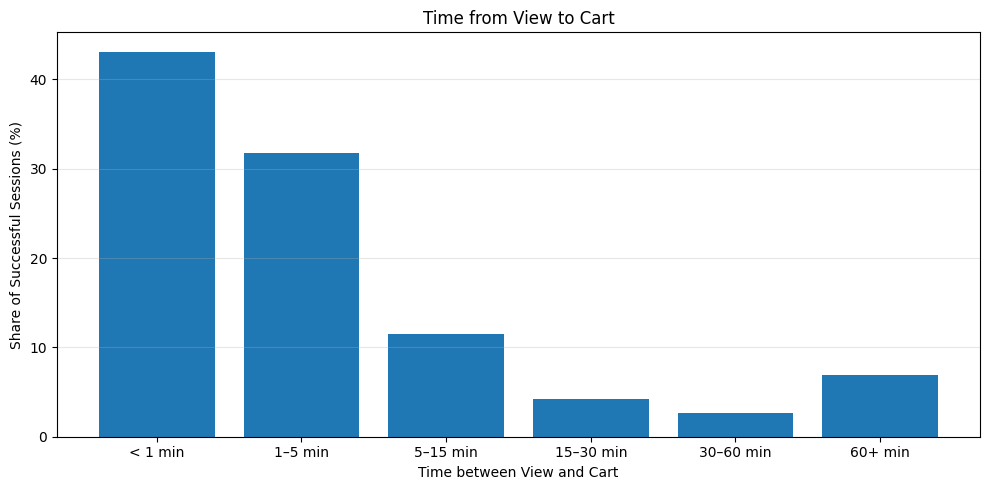

In [85]:
plt.figure(figsize=(10, 5))

plt.bar(view_to_cart_distribution['time_group'], view_to_cart_distribution['share'])

plt.title('Time from View to Cart')
plt.xlabel('Time between View and Cart')
plt.ylabel('Share of Successful Sessions (%)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The majority of successful sessions move from View to Cart very quickly: **43.11%** do so **within the first minute**, while another **31.73%** take **1-5 minutes**. Overall, 74.84% of successful sessions reach the cart within five minutes of the initial view.

Longer consideration periods are less common, with only **4.18%** of sessions taking **15-30 minutes** and **2.62%** taking **30-60 minutes**. However, **6.88%** of successful sessions take **more than an hour**, indicating a smaller but notable group of users with a much longer consideration period.

This suggests that for most successful sessions, the decision to add a product to the cart happens relatively quickly after viewing it, while a smaller group shows a substantially longer consideration period.

### Cart → Purchase

> How long does it take users to complete a purchase after adding a product to cart?

In [86]:
cart_to_purchase_distribution = time_conversion['cart_to_purchase_group'].value_counts().reindex(labels).reset_index()

cart_to_purchase_distribution.columns = ['time_group', 'sessions']

cart_to_purchase_distribution['share'] = round(cart_to_purchase_distribution['sessions'] / cart_to_purchase_distribution['sessions'].sum()* 100, 2)

cart_to_purchase_distribution

,time_group,sessions,share
0,< 1 min,5618,27.40
1,1–5 min,10747,52.41
2,5–15 min,2316,11.29
3,15–30 min,636,3.10
4,30–60 min,397,1.94
5,60+ min,792,3.86


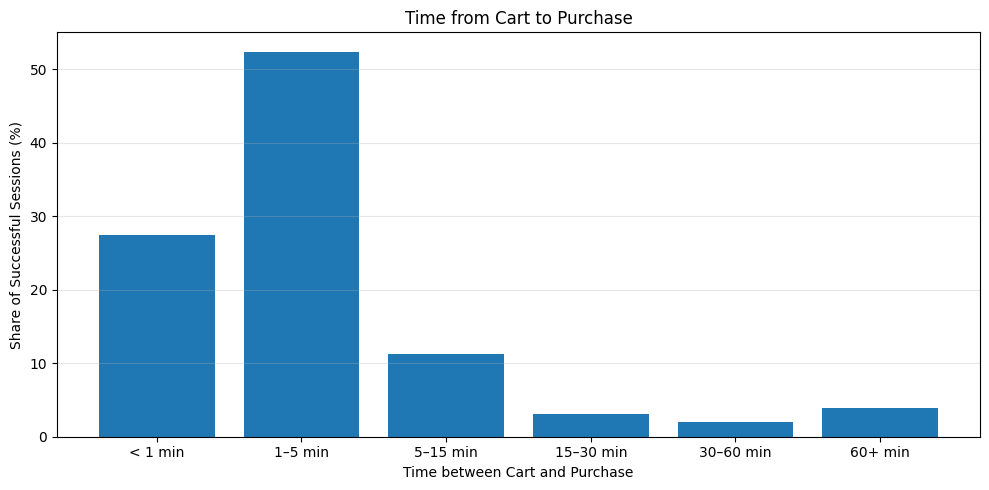

In [87]:
plt.figure(figsize=(10, 5))

plt.bar(cart_to_purchase_distribution['time_group'], cart_to_purchase_distribution['share'])

plt.title('Time from Cart to Purchase')
plt.xlabel('Time between Cart and Purchase')
plt.ylabel('Share of Successful Sessions (%)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The majority of successful sessions complete the purchase shortly after adding a product to the cart. The largest share, **52.41%**, converts within **1-5 minutes**, while another **27.40%** converts in **less than one minute**. Overall, 79.81% of successful sessions proceed from Cart to Purchase within five minutes.

Longer delays are relatively uncommon: only **11.29%** of sessions take **5-15 minutes**, while **3.10%** take **15-30 minutes** and **1.94%** take **30-60 minutes**. A further **3.86%** take **more than an hour**.

This indicates that among successful sessions, the transition from Cart to Purchase is generally very fast, with most purchases occurring within the first five minutes after adding a product to the cart.

## Data for Dashboard

In [91]:

# first category/brend/price
first_view = (
    df_clear[df_clear['event_type'] == 'view']
    .sort_values('event_time')
    .groupby('user_session')
    .first()[['category_code', 'brand', 'price', 'event_time']]
    .rename(columns={
        'category_code': 'entry_category',
        'brand': 'entry_brand',
        'price': 'entry_price'
    })
)

dashboard_sessions = session_funnel.merge(
    first_view,
    on='user_session',
    how='left'
)

# session start time
dashboard_sessions['hour'] = dashboard_sessions['event_time'].dt.hour
dashboard_sessions['weekday'] = dashboard_sessions['event_time'].dt.day_name()
dashboard_sessions['date'] = dashboard_sessions['event_time'].dt.strftime('%Y-%m-%d')

# Price segment
labels_price=['Low', 'Lower-Mid', 'Upper-Mid', 'High']
bins_price=[0, q1, q2, q3, session_price['price'].max()]

dashboard_sessions['price_segment'] = pd.cut(
    dashboard_sessions['entry_price'],
    bins=bins_price,
    labels=labels_price
)

# Time-to-conversion
dashboard_sessions = dashboard_sessions.merge(
    time_conversion[
        [
            'user_session',
            'view_to_cart_min',
            'cart_to_purchase_min',
            'view_to_cart_group',
            'cart_to_purchase_group'
        ]
    ],
    on='user_session',
    how='left'
)

# Funnel flags
dashboard_sessions['is_view'] = (
    dashboard_sessions['view_time'].notna().astype(int))

dashboard_sessions['is_cart'] = (
    dashboard_sessions['view_to_cart'].astype(int))

dashboard_sessions['is_purchase'] = (
    dashboard_sessions['successful_purchase'].astype(int))


dashboard_sessions.to_csv('dashboard_sessions.csv', index=False)

In [92]:
from google.colab import files

#files.download('dashboard_sessions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recommendations

### 1. Prioritize the View → Cart stage

The largest funnel bottleneck occurs between View and Cart, where 91.56% of sessions drop off. In comparison, Cart → Purchase performs considerably better, with a 50.25% drop-off.

**Recommendation**: Prioritize improvements to product-page experience, including clearer product information, pricing, availability and more prominent Add to Cart actions.

### 2. Investigate high-performing categories and brands

Conversion varies substantially across both product categories and brands. For example, computers.peripherals.camera reaches 12.60% overall conversion, while codyson reaches 16.45%. High-performing brands such as codyson and keenetic perform strongly across both funnel stages.

**Recommendation:** Analyze high-performing categories and brands to identify common characteristics - such as product type, assortment, pricing or customer demand - that could potentially be replicated across lower-performing segments.


### 3. Reduce purchase friction for high-priced products

The High-price segment has the strongest View → Cart rate (11.95%) but the lowest Cart → Purchase rate (43.12%). At the same time, it still has the highest overall conversion (5.15%).

**Recommendation:** Investigate the Cart → Purchase stage for high-priced products and test ways to reduce purchase hesitation, such as clearer delivery information, payment options, guarantees and return policies.


### 4. Prioritize high-intent time windows for testing

Conversion varies more by hour than by day of week. Hourly conversion reaches its highest level around 09:00-10:00 (4.61%), while weekday conversion varies only slightly, from 4.01% on Sunday to 4.35% on Tuesday.

**Recommendation:** Use higher-conversion time periods as candidates for testing targeted promotions, recommendations or other conversion-focused activities.


### 5. Preserve a fast purchase experience

Among successful sessions, 74.84% reach Cart within five minutes of the first View, and 79.81% complete the Purchase within five minutes of adding the product to Cart.

**Recommendation:** Maintain a fast and frictionless path from Cart to Purchase, while investigating sessions with substantially longer delays to identify potential checkout or decision-making friction.